# 06. Giảm chiều dữ liệu với PCA từ đầu (PCA from Scratch)

## 1. Cơ sở lý thuyết PCA
Principal Component Analysis (PCA) là phương pháp giảm chiều không giám sát (unsupervised). Các bước thực hiện:
1. Trừ giá trị trung bình để đưa dữ liệu về tâm 0: $X_c = X - \bar{X}$.
2. Tính ma trận hiệp phương sai: $C = \frac{1}{n-1} X_c^T X_c$.
3. Phân rã trị riêng và vector riêng: $C v = \lambda v$ bằng `np.linalg.eigh`.
4. Sắp xếp trị riêng giảm dần và chọn $k$ thành phần chính giữ lại phần lớn phương sai.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.dimensionality_reduction.pca import PCA
from src.models.logistic_regression import LogisticRegression
from src.metrics import calculate_metrics

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. Phân tích phương sai tích lũy (Cumulative Explained Variance)

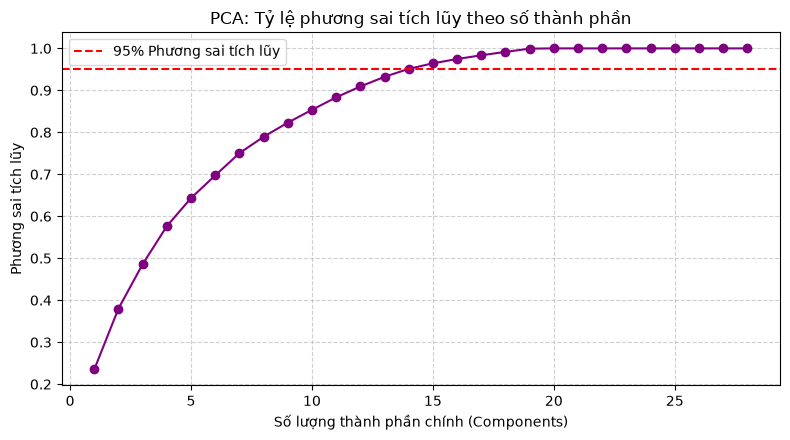

Số chiều gốc: 28
Số chiều cần để giữ 95% phương sai: 14


In [2]:
pca_full = PCA().fit(X_train_proc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='purple')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Phương sai tích lũy')
plt.title('PCA: Tỷ lệ phương sai tích lũy theo số thành phần')
plt.xlabel('Số lượng thành phần chính (Components)')
plt.ylabel('Phương sai tích lũy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

pca_95 = PCA(n_components=0.95).fit(X_train_proc)
print(f"Số chiều gốc: {X_train_proc.shape[1]}")
print(f"Số chiều cần để giữ 95% phương sai: {pca_95.n_components_}")

## 3. Trực quan hóa dữ liệu trong không gian 2D

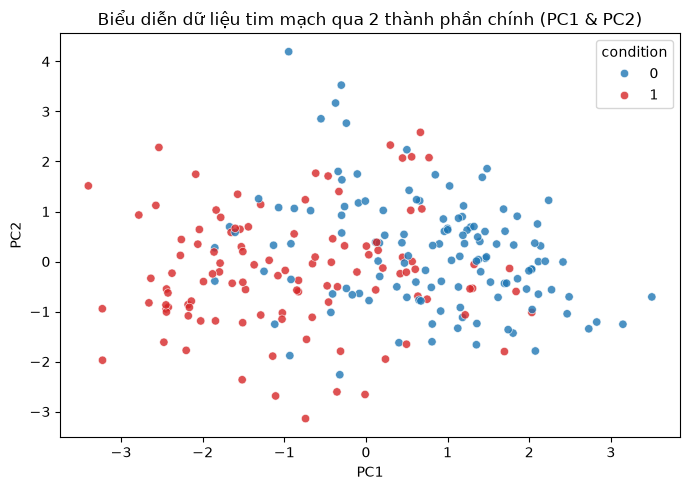

In [3]:
pca_2d = PCA(n_components=2).fit(X_train_proc)
X_train_2d = pca_2d.transform(X_train_proc)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train, palette=['#1f77b4', '#d62728'], alpha=0.8)
plt.title('Biểu diễn dữ liệu tim mạch qua 2 thành phần chính (PC1 & PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

## 4. Đánh giá phân loại sau khi giảm chiều (PCA + Logistic Regression)

In [4]:
X_train_pca = pca_95.transform(X_train_proc)
X_test_pca = pca_95.transform(X_test_proc)

lr_pca = LogisticRegression(learning_rate=0.05, epochs=1500, l2=0.01, random_state=42)
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
y_proba_pca = lr_pca.predict_proba(X_test_pca)[:, 1]
metrics_pca = calculate_metrics(y_test, y_pred_pca, y_proba_pca)

print("Kết quả Logistic Regression sau PCA (giữ 95% phương sai):")
for k, v in metrics_pca.items():
    print(f"  {k}: {v:.4f}")

Kết quả Logistic Regression sau PCA (giữ 95% phương sai):
  Accuracy: 0.8644
  Precision: 0.8276
  Recall: 0.8889
  F1_Score: 0.8571
  ROC_AUC: 0.9329


## 5. Phân tích kết quả
- PCA giúp giảm số chiều đáng kể mà vẫn giữ lại 95% thông tin quan trọng.
- Hiệu năng phân loại của Logistic Regression sau PCA vẫn tương đương hoặc chỉ suy giảm nhẹ, đồng thời giảm chi phí tính toán và loại bớt nhiễu đa cộng tuyến.